What are the most demanded skills for the top 3 most popular roles?
Methodology
1. Clean up skill column
2. Calculate the skill count based on job_title_short
3. Calculate the skill percentage
4. Plot final findings

In [2]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_UK = df[df['job_country'] == 'United Kingdom']

df_skills = df_UK.explode('job_skills')
df_skills[['job_title', 'job_skills']]

,job_title,job_skills
15,Data Engineer,python
15,Data Engineer,sql
15,Data Engineer,power bi
45,Senior Data Analyst,sql
45,Senior Data Analyst,python
...,...,...
785642,Submission for the position: Data Engineer Sen...,qlik
785642,Submission for the position: Data Engineer Sen...,confluence
785642,Submission for the position: Data Engineer Sen...,jira
785676,Senior Data Scientist,r


In [4]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1163,sql,Data Engineer,7050
915,python,Data Engineer,6462
916,python,Data Scientist,6329
88,azure,Data Engineer,4865
1162,sql,Data Analyst,4467
...,...,...,...
1368,vue.js,Software Engineer,1
1367,vue.js,Senior Data Engineer,1
514,javascript,Machine Learning Engineer,1
551,julia,Software Engineer,1


Create a list of top 3 roles

In [5]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

Plot Skill Counts

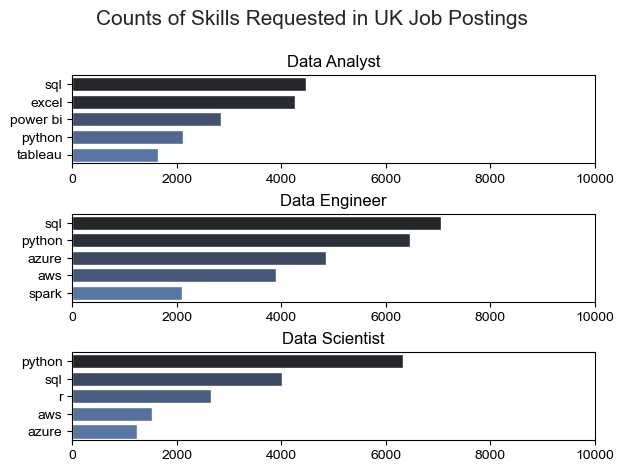

In [6]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 10000)

fig.suptitle('Counts of Skills Requested in UK Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

Convert Counts to Percentages

In [7]:
df_job_title_count = df_UK['job_title_short'].value_counts().reset_index(name='jobs_total')
df_job_title_count

,job_title_short,jobs_total
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367
5,Senior Data Analyst,1356
6,Business Analyst,827
7,Software Engineer,541
8,Machine Learning Engineer,317
9,Cloud Engineer,193


In [8]:
# First, make sure you have the numeric percentage column
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_perc_numeric'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100
df_skills_perc['skill_perc'] = df_skills_perc['skill_perc_numeric'].round(1).astype(str) + '%'

# Verify the columns exist
print(df_skills_perc.columns.tolist())

['job_skills', 'job_title_short', 'skill_count', 'jobs_total', 'skill_perc_numeric', 'skill_perc']


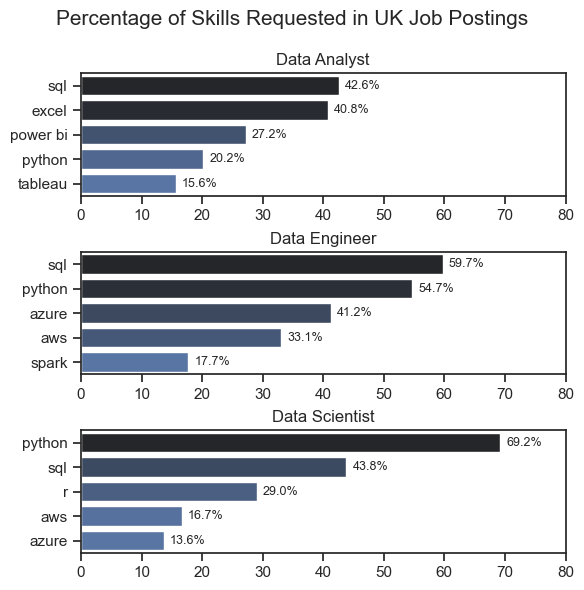

In [9]:
# Merge and calculate percentages
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_perc_numeric'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100
df_skills_perc['skill_perc'] = df_skills_perc['skill_perc_numeric'].round(1).astype(str) + '%'

# Create the plots
fig, ax = plt.subplots(len(job_titles), 1, figsize=(6, 6))

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)[::-1]
    
    # Create barplot
    sns.barplot(data=df_plot, x='skill_perc_numeric', y='job_skills', ax=ax[i], 
                hue='skill_perc_numeric', palette='dark:b_r', legend=False)
    
    # Add percentage labels on each bar
    for j, (idx, row) in enumerate(df_plot.iterrows()):
        ax[i].text(row['skill_perc_numeric'] + 1, j, 
                   f"{row['skill_perc_numeric']:.1f}%", 
                   va='center', fontsize=9)
    
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 80)

fig.suptitle('Percentage of Skills Requested in UK Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()